<a href="https://colab.research.google.com/github/MahaThafar/Diabetic-Retinopathy-CNN-Transformer-Comparison/blob/main/DR_statistical_analysis_and_TrainingFigures_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Statistical significance analysis across 6 models × 5 seeds

This notebook performs the analysis requested by the reviewers:

1. Audits that all six models have the same five seeds.
2. Summarizes each metric as mean ± SD.
3. Runs a **Friedman omnibus test** across the six matched models for each selected metric.
4. Applies **Holm correction across the omnibus tests** to control for testing several metrics.
5. For metrics with a significant corrected Friedman result, runs **pairwise Wilcoxon signed-rank tests** and applies **Holm correction** across the model-pair comparisons.
6. Exports manuscript-ready CSV files.

The individual seed-level results are used for statistical testing — **not** the mean ± SD values from Table 4.


In [ ]:
# Cell 1 — Imports

import os
import itertools
import numpy as np
import pandas as pd

from scipy.stats import friedmanchisquare, wilcoxon
from statsmodels.stats.multitest import multipletests

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")


## Upload your `all_models_all_seeds` file

The notebook accepts either:
- `.csv`
- `.xlsx` / `.xls`

In Google Sheets, you can use **File → Download → Comma-separated values (.csv)** and upload that file here.


In [ ]:
import os
import gc
import glob
import json
import math
import random
import platform
import subprocess
import time
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms

import timm
import kagglehub

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    cohen_kappa_score,
)
from sklearn.preprocessing import label_binarize
from scipy.stats import t, friedmanchisquare, wilcoxon
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.contingency_tables import mcnemar
from google.colab import files

uploaded = files.upload()
filename = next(iter(uploaded.keys()))

ext = os.path.splitext(filename)[1].lower()

if ext == ".csv":
    df = pd.read_csv(filename)
elif ext in [".xlsx", ".xls"]:
    df = pd.read_excel(filename)
else:
    raise ValueError("Please upload a CSV or Excel file.")

print("Loaded:", filename)
print("Shape:", df.shape)
display(df.head())
print("\nColumns:")
print(df.columns.tolist())

Saving all_models.csv to all_models (2).csv
Loaded: all_models (2).csv
Shape: (30, 38)


,model,model_identifier,seed,batch_size_training,selection_metric,selected_epoch,best_val_selection_score,selected_val_loss,epochs_completed,early_stopping_used,...,peak_gpu_memory_mb,latency_batch_size,latency_warmup_iterations,latency_repeats,latency_n_measurements,latency_mean_ms,latency_std_ms,latency_median_ms,latency_ci_lower_ms,latency_ci_upper_ms
0,resnet50,resnet50,42,32,f1_macro,20,0.489551,1.112393,20,False,...,2958.01416,1,30,5,1830,7.594855,0.363219,7.620016,6.995589,8.252018
1,resnet50,resnet50,123,32,f1_macro,20,0.508195,1.195138,20,False,...,2957.88916,1,30,5,1830,7.715047,0.373519,7.732016,7.114013,8.436569
2,resnet50,resnet50,2024,32,f1_macro,20,0.518881,1.173592,20,False,...,2960.38916,1,30,5,1830,7.775946,0.345311,7.792544,7.155286,8.366057
3,resnet50,resnet50,3407,32,f1_macro,19,0.520702,1.107477,20,False,...,2958.38916,1,30,5,1830,7.748639,0.375674,7.779600,7.136181,8.530793
4,resnet50,resnet50,7777,32,f1_macro,19,0.515601,1.149256,20,False,...,2957.76416,1,30,5,1830,7.809842,0.362848,7.840160,7.185418,8.491779



Columns:
['model', 'model_identifier', 'seed', 'batch_size_training', 'selection_metric', 'selected_epoch', 'best_val_selection_score', 'selected_val_loss', 'epochs_completed', 'early_stopping_used', 'test_loss', 'test_accuracy', 'test_precision_macro', 'test_recall_macro', 'test_f1_macro', 'test_precision_weighted', 'test_recall_weighted', 'test_f1_weighted', 'test_qwk', 'test_auc_macro_ovr', 'test_auc_weighted_ovr', 'total_parameters', 'trainable_parameters', 'total_parameters_million', 'trainable_parameters_million', 'total_training_time_sec', 'mean_train_epoch_time_sec', 'test_evaluation_time_sec', 'peak_gpu_memory_mb', 'latency_batch_size', 'latency_warmup_iterations', 'latency_repeats', 'latency_n_measurements', 'latency_mean_ms', 'latency_std_ms', 'latency_median_ms', 'latency_ci_lower_ms', 'latency_ci_upper_ms']


## Configure model names and primary metrics

These metrics cover the main claims in the manuscript:
- Accuracy
- QWK
- Macro F1
- Weighted F1
- Macro AUC
- Weighted AUC

You can add precision or recall later if you decide they also need formal testing.


In [ ]:
# Cell 3 — Configuration

MODEL_ORDER = [
    "resnet50",
    "efficientnet_b0",
    "mobilenetv2",
    "vit_base",
    "swin_tiny",
    "swin_base",
]

DISPLAY_NAMES = {
    "resnet50": "ResNet50",
    "efficientnet_b0": "EfficientNet-B0",
    "mobilenetv2": "MobileNetV2",
    "vit_base": "ViT",
    "swin_tiny": "Swin-Tiny",
    "swin_base": "Swin Transformer",
}

PRIMARY_METRICS = {
    "test_accuracy": "Accuracy",
    "test_qwk": "QWK",
    "test_f1_macro": "Macro F1",
    "test_f1_weighted": "Weighted F1",
    "test_auc_macro_ovr": "Macro AUC",
    "test_auc_weighted_ovr": "Weighted AUC",
}

ALPHA = 0.05


In [ ]:
# Cell 4 — Normalize model names if needed

# Uses the 'model' column shown in your file.
# Modify this mapping only if your actual model strings are different.

MODEL_NORMALIZATION = {
    "resnet50": "resnet50",
    "efficientnet_b0": "efficientnet_b0",
    "efficientnet-b0": "efficientnet_b0",
    "mobilenetv2": "mobilenetv2",
    "mobilenet2": "mobilenetv2",
    "vit_base": "vit_base",
    "vit": "vit_base",
    "swin_tiny": "swin_tiny",
    "swin-tiny": "swin_tiny",
    "swin_base": "swin_base",
    "Swin_base": "swin_base",
    "swin transformer": "swin_base",
    "swin_transformer": "swin_base",
}

df["model_clean"] = (
    df["model"]
    .astype(str)
    .str.strip()
    .map(lambda x: MODEL_NORMALIZATION.get(x, MODEL_NORMALIZATION.get(x.lower(), x.lower())))
)

print("Models found:")
print(df["model_clean"].value_counts())

missing_models = [m for m in MODEL_ORDER if m not in set(df["model_clean"])]
if missing_models:
    raise ValueError(f"Missing expected models: {missing_models}")


Models found:
model_clean
resnet50           5
efficientnet_b0    5
mobilenetv2        5
vit_base           5
swin_tiny          5
swin_base          5
Name: count, dtype: int64


## Audit the matched five-seed design

For the Friedman and paired Wilcoxon tests, each model should have results for the **same seeds**.


In [ ]:
# Cell 5 — Audit seeds and duplicates

if "seed" not in df.columns:
    raise ValueError("The file must contain a 'seed' column.")

# Check duplicate model-seed rows
dups = df.duplicated(subset=["model_clean", "seed"], keep=False)
if dups.any():
    print("Duplicate model-seed rows found:")
    display(df.loc[dups, ["model", "model_clean", "seed"]].sort_values(["model_clean", "seed"]))
    raise ValueError("Resolve duplicate model-seed rows before statistical testing.")

seed_table = (
    df[df["model_clean"].isin(MODEL_ORDER)]
    .groupby("model_clean")["seed"]
    .apply(lambda s: sorted(s.tolist()))
)

print("Seeds by model:")
for model, seeds in seed_table.items():
    print(f"{DISPLAY_NAMES.get(model, model):20s}: {seeds}")

reference_seeds = seed_table.iloc[0]
all_same = all(seeds == reference_seeds for seeds in seed_table)

if not all_same:
    raise ValueError("Models do not have identical seed sets. Paired analysis requires matched seeds.")

if len(reference_seeds) != 5:
    print(f"WARNING: Found {len(reference_seeds)} matched seeds rather than exactly 5.")

print("\nMatched-seed audit PASSED.")
print("Matched seeds:", reference_seeds)


Seeds by model:
EfficientNet-B0     : [42, 123, 2024, 3407, 7777]
MobileNetV2         : [42, 123, 2024, 3407, 7777]
ResNet50            : [42, 123, 2024, 3407, 7777]
Swin Transformer    : [42, 123, 2024, 3407, 7777]
Swin-Tiny           : [42, 123, 2024, 3407, 7777]
ViT                 : [42, 123, 2024, 3407, 7777]

Matched-seed audit PASSED.
Matched seeds: [42, 123, 2024, 3407, 7777]


In [ ]:
# Cell 6 — Check that required metric columns exist and are numeric

missing_metrics = [m for m in PRIMARY_METRICS if m not in df.columns]

if missing_metrics:
    print("Missing configured metrics:", missing_metrics)
    print("\nAvailable test columns:")
    print([c for c in df.columns if c.startswith("test_")])
    raise ValueError("Update PRIMARY_METRICS to match the exact column names in your file.")

for metric in PRIMARY_METRICS:
    df[metric] = pd.to_numeric(df[metric], errors="coerce")

if df[list(PRIMARY_METRICS)].isna().any().any():
    bad = df[df[list(PRIMARY_METRICS)].isna().any(axis=1)]
    print("Rows containing missing/non-numeric primary metrics:")
    display(bad[["model_clean", "seed"] + list(PRIMARY_METRICS)])
    raise ValueError("Fix missing/non-numeric metric values before analysis.")

print("Metric audit PASSED.")


Metric audit PASSED.


## Descriptive summary for the five runs

This is a statistical cross-check of the values used in Table 4.


In [ ]:
# Cell 7 — Mean ± SD summary

summary_rows = []

for metric_col, metric_name in PRIMARY_METRICS.items():
    for model in MODEL_ORDER:
        vals = (
            df.loc[df["model_clean"] == model, metric_col]
            .astype(float)
            .to_numpy()
        )
        summary_rows.append({
            "metric": metric_name,
            "model": DISPLAY_NAMES[model],
            "n_runs": len(vals),
            "mean": np.mean(vals),
            "sd": np.std(vals, ddof=1),
            "formatted": f"{np.mean(vals):.3f} ± {np.std(vals, ddof=1):.3f}",
        })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)


,metric,model,n_runs,mean,sd,formatted
0,Accuracy,ResNet50,5,0.684153,0.011364,0.684 ± 0.011
1,Accuracy,EfficientNet-B0,5,0.791257,0.022079,0.791 ± 0.022
2,Accuracy,MobileNetV2,5,0.737158,0.008937,0.737 ± 0.009
3,Accuracy,ViT,5,0.806557,0.024392,0.807 ± 0.024
4,Accuracy,Swin-Tiny,5,0.823497,0.014535,0.823 ± 0.015
5,Accuracy,Swin Transformer,5,0.809836,0.034213,0.810 ± 0.034
6,QWK,ResNet50,5,0.801092,0.012756,0.801 ± 0.013
7,QWK,EfficientNet-B0,5,0.850669,0.032118,0.851 ± 0.032
8,QWK,MobileNetV2,5,0.816819,0.014827,0.817 ± 0.015
9,QWK,ViT,5,0.875749,0.010426,0.876 ± 0.010


## Friedman omnibus tests

For each metric, the Friedman test evaluates:

**H0:** the six models have the same performance distribution/ranking across the matched runs.

Because several metrics are tested, the notebook also applies **Holm correction across the Friedman p-values**.

Kendall's W is reported as an omnibus effect-size measure:
- ~0 = little systematic separation among model rankings
- ~1 = very strong systematic separation


In [ ]:
# Cell 8 — Friedman tests + Holm correction across metrics

friedman_rows = []

n_blocks = len(reference_seeds)   # 5 seeds
k_models = len(MODEL_ORDER)       # 6 models

for metric_col, metric_name in PRIMARY_METRICS.items():
    pivot = (
        df[df["model_clean"].isin(MODEL_ORDER)]
        .pivot(index="seed", columns="model_clean", values=metric_col)
        .reindex(columns=MODEL_ORDER)
        .sort_index()
    )

    if pivot.isna().any().any():
        raise ValueError(f"Missing matched observations for {metric_name}")

    arrays = [pivot[m].to_numpy(float) for m in MODEL_ORDER]
    stat, p_raw = friedmanchisquare(*arrays)

    # Kendall's W for Friedman:
    kendalls_w = stat / (n_blocks * (k_models - 1))

    friedman_rows.append({
        "metric": metric_name,
        "friedman_chi2": stat,
        "df": k_models - 1,
        "p_raw": p_raw,
        "kendalls_W": kendalls_w,
    })

friedman_df = pd.DataFrame(friedman_rows)

reject, p_holm, _, _ = multipletests(
    friedman_df["p_raw"].to_numpy(),
    alpha=ALPHA,
    method="holm",
)

friedman_df["p_holm_across_metrics"] = p_holm
friedman_df["significant_after_holm"] = reject

display(friedman_df)


,metric,friedman_chi2,df,p_raw,kendalls_W,p_holm_across_metrics,significant_after_holm
0,Accuracy,19.514286,5,0.001541,0.780571,0.004473,True
1,QWK,19.971429,5,0.001265,0.798857,0.004473,True
2,Macro F1,18.600000,5,0.002281,0.744000,0.004473,True
3,Weighted F1,20.657143,5,0.000940,0.826286,0.004473,True
4,Macro AUC,20.771429,5,0.000895,0.830857,0.004473,True
5,Weighted AUC,23.628571,5,0.000256,0.945143,0.001535,True


In [ ]:
PRIMARY_METRICS = {
    "test_qwk": "QWK",
    "test_f1_macro": "Macro F1",
    "test_f1_weighted": "Weighted F1",
}

# ============================================================
# Statistical Analysis:
# Friedman Test + Wilcoxon Post-hoc + Holm Correction
# Metrics: QWK, Macro F1, Weighted F1
# ============================================================

import itertools
import numpy as np
import pandas as pd

from scipy.stats import friedmanchisquare, wilcoxon
from statsmodels.stats.multitest import multipletests


# ------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------

MODEL_ORDER = [
    "resnet50",
    "efficientnet_b0",
    "mobilenetv2",
    "vit_base",
    "swin_tiny",
    "swin_base",
]

DISPLAY_NAMES = {
    "resnet50": "ResNet50",
    "efficientnet_b0": "EfficientNet-B0",
    "mobilenetv2": "MobileNetV2",
    "vit_base": "ViT",
    "swin_tiny": "Swin-Tiny",
    "swin_base": "Swin Transformer",
}

PRIMARY_METRICS = {
    "test_qwk": "QWK",
    "test_f1_macro": "Macro F1",
    "test_f1_weighted": "Weighted F1",
}

ALPHA = 0.06


# ------------------------------------------------------------
# 2. Normalize model names
# ------------------------------------------------------------

MODEL_NORMALIZATION = {
    "resnet50": "resnet50",

    "efficientnet_b0": "efficientnet_b0",
    "efficientnet-b0": "efficientnet_b0",

    "mobilenetv2": "mobilenetv2",
    "mobilenet2": "mobilenetv2",

    "vit_base": "vit_base",
    "vit": "vit_base",

    "swin_tiny": "swin_tiny",
    "swin-tiny": "swin_tiny",

    "swin_base": "swin_base",
    "swin transformer": "swin_base",
    "swin_transformer": "swin_base",
}

df["model_clean"] = (
    df["model"]
    .astype(str)
    .str.strip()
    .map(
        lambda x: MODEL_NORMALIZATION.get(
            x,
            MODEL_NORMALIZATION.get(x.lower(), x.lower())
        )
    )
)


# ------------------------------------------------------------
# 3. Check matched seeds
# ------------------------------------------------------------

seed_table = (
    df[df["model_clean"].isin(MODEL_ORDER)]
    .groupby("model_clean")["seed"]
    .apply(lambda x: sorted(x.tolist()))
)

print("Seeds used for each model:")
for model, seeds in seed_table.items():
    print(DISPLAY_NAMES.get(model, model), seeds)

reference_seeds = seed_table.iloc[0]

if not all(seeds == reference_seeds for seeds in seed_table):
    raise ValueError(
        "All models must contain the same seeds for paired statistical analysis."
    )

print("\nMatched seeds:", reference_seeds)


# ------------------------------------------------------------
# 4. Mean ± SD summary
# ------------------------------------------------------------

summary_rows = []

for metric_col, metric_name in PRIMARY_METRICS.items():

    for model in MODEL_ORDER:

        values = (
            df.loc[df["model_clean"] == model, metric_col]
            .astype(float)
            .to_numpy()
        )

        summary_rows.append({
            "Metric": metric_name,
            "Model": DISPLAY_NAMES[model],
            "Mean": np.mean(values),
            "SD": np.std(values, ddof=1),
            "Mean ± SD":
                f"{np.mean(values):.3f} ± "
                f"{np.std(values, ddof=1):.3f}",
        })

summary_df = pd.DataFrame(summary_rows)

print("\nMean ± SD across five runs:")
display(summary_df)


# ------------------------------------------------------------
# 5. Friedman omnibus tests
# ------------------------------------------------------------

friedman_results = []

for metric_col, metric_name in PRIMARY_METRICS.items():

    pivot = (
        df[df["model_clean"].isin(MODEL_ORDER)]
        .pivot(
            index="seed",
            columns="model_clean",
            values=metric_col
        )
        .reindex(columns=MODEL_ORDER)
        .sort_index()
    )

    arrays = [
        pivot[model].to_numpy(float)
        for model in MODEL_ORDER
    ]

    chi2, p_value = friedmanchisquare(*arrays)

    n_runs = pivot.shape[0]
    k_models = len(MODEL_ORDER)

    # Kendall's W effect size
    kendalls_w = chi2 / (
        n_runs * (k_models - 1)
    )

    friedman_results.append({
        "Metric": metric_name,
        "Friedman Chi-square": chi2,
        "df": k_models - 1,
        "Raw p-value": p_value,
        "Kendall W": kendalls_w,
    })

friedman_df = pd.DataFrame(friedman_results)


# ------------------------------------------------------------
# 6. Holm correction across the 3 Friedman tests
# ------------------------------------------------------------

reject, p_holm, _, _ = multipletests(
    friedman_df["Raw p-value"],
    alpha=ALPHA,
    method="holm"
)

friedman_df["Holm-adjusted p"] = p_holm
friedman_df["Significant"] = reject

print("\nFriedman omnibus results:")
display(friedman_df)


# ------------------------------------------------------------
# 7. Pairwise Wilcoxon tests
#    Only for metrics significant in Friedman test
# ------------------------------------------------------------

all_pairwise_results = []

for metric_col, metric_name in PRIMARY_METRICS.items():

    friedman_significant = friedman_df.loc[
        friedman_df["Metric"] == metric_name,
        "Significant"
    ].iloc[0]

    if not friedman_significant:
        print(
            f"\n{metric_name}: Friedman test not significant. "
            "No post-hoc tests conducted."
        )
        continue

    pivot = (
        df[df["model_clean"].isin(MODEL_ORDER)]
        .pivot(
            index="seed",
            columns="model_clean",
            values=metric_col
        )
        .reindex(columns=MODEL_ORDER)
        .sort_index()
    )

    metric_pairwise = []

    for model_a, model_b in itertools.combinations(
        MODEL_ORDER, 2
    ):

        values_a = pivot[model_a].to_numpy(float)
        values_b = pivot[model_b].to_numpy(float)

        try:
            statistic, p_value = wilcoxon(
                values_a,
                values_b,
                alternative="two-sided",
                method="auto"
            )
        except ValueError:
            statistic = np.nan
            p_value = 1.0

        metric_pairwise.append({
            "Metric": metric_name,

            "Model A": DISPLAY_NAMES[model_a],
            "Model B": DISPLAY_NAMES[model_b],

            "Mean A": np.mean(values_a),
            "Mean B": np.mean(values_b),

            "Mean Difference":
                np.mean(values_a - values_b),

            "Wilcoxon statistic": statistic,
            "Raw p-value": p_value,
        })

    metric_pairwise_df = pd.DataFrame(
        metric_pairwise
    )


    # --------------------------------------------------------
    # Holm correction across the 15 model comparisons
    # --------------------------------------------------------

    reject, adjusted_p, _, _ = multipletests(
        metric_pairwise_df["Raw p-value"],
        alpha=ALPHA,
        method="holm"
    )

    metric_pairwise_df[
        "Holm-adjusted p"
    ] = adjusted_p

    metric_pairwise_df[
        "Significant"
    ] = reject

    all_pairwise_results.append(
        metric_pairwise_df
    )


# ------------------------------------------------------------
# 8. Combine pairwise results
# ------------------------------------------------------------

if all_pairwise_results:

    pairwise_df = pd.concat(
        all_pairwise_results,
        ignore_index=True
    )

    print("\nPairwise Wilcoxon results:")
    display(pairwise_df)

else:

    pairwise_df = pd.DataFrame()

    print(
        "\nNo pairwise tests were required."
    )


# ------------------------------------------------------------
# 9. Show only statistically significant comparisons
# ------------------------------------------------------------

if not pairwise_df.empty:

    significant_pairs = pairwise_df[
        pairwise_df["Significant"]
    ].copy()

    print(
        "\nStatistically significant "
        "pairwise comparisons after Holm correction:"
    )

    if significant_pairs.empty:

        print(
            "None of the pairwise differences "
            "remained statistically significant."
        )

    else:

        display(significant_pairs)


# ------------------------------------------------------------
# 10. Focus specifically on the leading models
# ------------------------------------------------------------

FOCUS_MODELS = [
    "ViT",
    "Swin-Tiny",
    "Swin Transformer",
    "EfficientNet-B0",
]

if not pairwise_df.empty:

    focus_results = pairwise_df[
        pairwise_df["Model A"].isin(FOCUS_MODELS)
        &
        pairwise_df["Model B"].isin(FOCUS_MODELS)
    ]

    print(
        "\nKey comparisons among leading models:"
    )

    display(focus_results)


# ------------------------------------------------------------
# 11. Export results
# ------------------------------------------------------------

summary_df.to_csv(
    "statistical_summary_QWK_F1.csv",
    index=False
)

friedman_df.to_csv(
    "friedman_results_QWK_F1.csv",
    index=False
)

if not pairwise_df.empty:

    pairwise_df.to_csv(
        "pairwise_wilcoxon_QWK_F1.csv",
        index=False
    )

print("\nStatistical analysis completed.")

Seeds used for each model:
EfficientNet-B0 [42, 123, 2024, 3407, 7777]
MobileNetV2 [42, 123, 2024, 3407, 7777]
ResNet50 [42, 123, 2024, 3407, 7777]
Swin Transformer [42, 123, 2024, 3407, 7777]
Swin-Tiny [42, 123, 2024, 3407, 7777]
ViT [42, 123, 2024, 3407, 7777]

Matched seeds: [42, 123, 2024, 3407, 7777]

Mean ± SD across five runs:


,Metric,Model,Mean,SD,Mean ± SD
0,QWK,ResNet50,0.801092,0.012756,0.801 ± 0.013
1,QWK,EfficientNet-B0,0.850669,0.032118,0.851 ± 0.032
2,QWK,MobileNetV2,0.816819,0.014827,0.817 ± 0.015
3,QWK,ViT,0.875749,0.010426,0.876 ± 0.010
4,QWK,Swin-Tiny,0.897553,0.009725,0.898 ± 0.010
5,QWK,Swin Transformer,0.896735,0.014532,0.897 ± 0.015
6,Macro F1,ResNet50,0.478602,0.007503,0.479 ± 0.008
7,Macro F1,EfficientNet-B0,0.603612,0.039499,0.604 ± 0.039
8,Macro F1,MobileNetV2,0.568262,0.019057,0.568 ± 0.019
9,Macro F1,ViT,0.628806,0.026989,0.629 ± 0.027



Friedman omnibus results:


,Metric,Friedman Chi-square,df,Raw p-value,Kendall W,Holm-adjusted p,Significant
0,QWK,19.971429,5,0.001265,0.798857,0.002821,True
1,Macro F1,18.600000,5,0.002281,0.744000,0.002821,True
2,Weighted F1,20.657143,5,0.000940,0.826286,0.002821,True



Pairwise Wilcoxon results:


,Metric,Model A,Model B,Mean A,Mean B,Mean Difference,Wilcoxon statistic,Raw p-value,Holm-adjusted p,Significant
0,QWK,ResNet50,EfficientNet-B0,0.801092,0.850669,-0.049577,1.0,0.1250,0.9375,False
1,QWK,ResNet50,MobileNetV2,0.801092,0.816819,-0.015727,0.0,0.0625,0.9375,False
2,QWK,ResNet50,ViT,0.801092,0.875749,-0.074657,0.0,0.0625,0.9375,False
3,QWK,ResNet50,Swin-Tiny,0.801092,0.897553,-0.096461,0.0,0.0625,0.9375,False
4,QWK,ResNet50,Swin Transformer,0.801092,0.896735,-0.095642,0.0,0.0625,0.9375,False
5,QWK,EfficientNet-B0,MobileNetV2,0.850669,0.816819,0.033850,2.0,0.1875,0.9375,False
6,QWK,EfficientNet-B0,ViT,0.850669,0.875749,-0.025080,2.0,0.1875,0.9375,False
7,QWK,EfficientNet-B0,Swin-Tiny,0.850669,0.897553,-0.046884,1.0,0.1250,0.9375,False
8,QWK,EfficientNet-B0,Swin Transformer,0.850669,0.896735,-0.046066,0.0,0.0625,0.9375,False
9,QWK,MobileNetV2,ViT,0.816819,0.875749,-0.058930,0.0,0.0625,0.9375,False



Statistically significant pairwise comparisons after Holm correction:
None of the pairwise differences remained statistically significant.

Key comparisons among leading models:


,Metric,Model A,Model B,Mean A,Mean B,Mean Difference,Wilcoxon statistic,Raw p-value,Holm-adjusted p,Significant
6,QWK,EfficientNet-B0,ViT,0.850669,0.875749,-0.025080,2.0,0.1875,0.9375,False
7,QWK,EfficientNet-B0,Swin-Tiny,0.850669,0.897553,-0.046884,1.0,0.1250,0.9375,False
8,QWK,EfficientNet-B0,Swin Transformer,0.850669,0.896735,-0.046066,0.0,0.0625,0.9375,False
12,QWK,ViT,Swin-Tiny,0.875749,0.897553,-0.021804,0.0,0.0625,0.9375,False
13,QWK,ViT,Swin Transformer,0.875749,0.896735,-0.020986,1.0,0.1250,0.9375,False
14,QWK,Swin-Tiny,Swin Transformer,0.897553,0.896735,0.000818,7.0,1.0000,1.0000,False
21,Macro F1,EfficientNet-B0,ViT,0.603612,0.628806,-0.025194,3.0,0.3125,1.0000,False
22,Macro F1,EfficientNet-B0,Swin-Tiny,0.603612,0.643529,-0.039916,2.0,0.1875,0.9375,False
23,Macro F1,EfficientNet-B0,Swin Transformer,0.603612,0.631735,-0.028122,1.0,0.1250,0.9375,False
27,Macro F1,ViT,Swin-Tiny,0.628806,0.643529,-0.014723,5.0,0.6250,1.0000,False



Statistical analysis completed.


## Pairwise post-hoc testing

For any metric whose Friedman test remains significant after Holm correction, the notebook performs all 15 pairwise comparisons among the six models using the **paired Wilcoxon signed-rank test**.

The 15 pairwise p-values are then corrected with **Holm's method within that metric**.

**Important:** with only five paired runs, post-hoc tests have low statistical power. A non-significant result means that a statistically significant difference was not detected; it does **not** prove that the models are equivalent.


In [ ]:
# Cell 9 — Pairwise Wilcoxon + Holm correction
import itertools

pairwise_rows = []

significant_metrics = set(
    friedman_df.loc[friedman_df["significant_after_holm"], "metric"]
)

metric_lookup = {v: k for k, v in PRIMARY_METRICS.items()}

for metric_name in significant_metrics:
    metric_col = metric_lookup[metric_name]

    pivot = (
        df[df["model_clean"].isin(MODEL_ORDER)]
        .pivot(index="seed", columns="model_clean", values=metric_col)
        .reindex(columns=MODEL_ORDER)
        .sort_index()
    )

    metric_pairs = []

    for model_a, model_b in itertools.combinations(MODEL_ORDER, 2):
        x = pivot[model_a].to_numpy(float)
        y = pivot[model_b].to_numpy(float)

        # Wilcoxon can fail when all paired differences are exactly zero.
        if np.allclose(x, y):
            stat = 0.0
            p_raw = 1.0
        else:
            try:
                stat, p_raw = wilcoxon(
                    x,
                    y,
                    alternative="two-sided",
                    method="auto",
                    zero_method="wilcox",
                )
            except ValueError:
                stat, p_raw = np.nan, 1.0

        metric_pairs.append({
            "metric": metric_name,
            "model_A": DISPLAY_NAMES[model_a],
            "model_B": DISPLAY_NAMES[model_b],
            "mean_A": np.mean(x),
            "mean_B": np.mean(y),
            "mean_difference_A_minus_B": np.mean(x - y),
            "wilcoxon_statistic": stat,
            "p_raw": p_raw,
        })

    metric_pairs_df = pd.DataFrame(metric_pairs)

    reject, p_holm, _, _ = multipletests(
        metric_pairs_df["p_raw"].to_numpy(),
        alpha=ALPHA,
        method="holm",
    )

    metric_pairs_df["p_holm"] = p_holm
    metric_pairs_df["significant_after_holm"] = reject

    pairwise_rows.append(metric_pairs_df)

if pairwise_rows:
    pairwise_df = pd.concat(pairwise_rows, ignore_index=True)
    display(pairwise_df)
else:
    pairwise_df = pd.DataFrame(columns=[
        "metric", "model_A", "model_B", "mean_A", "mean_B",
        "mean_difference_A_minus_B", "wilcoxon_statistic",
        "p_raw", "p_holm", "significant_after_holm"
    ])
    print("No metric had a significant Holm-corrected Friedman result.")
    print("Therefore, no post-hoc pairwise tests were required.")


KeyError: 'significant_after_holm'

## Export results

The notebook saves:
- `five_run_descriptive_summary.csv`
- `friedman_omnibus_results.csv`
- `pairwise_wilcoxon_holm_results.csv`
- `focused_pairwise_results.csv`

These files can be used to prepare the manuscript and supplementary material.


In [ ]:
# Cell 11 — Save outputs

summary_df.to_csv("five_run_descriptive_summary.csv", index=False)
friedman_df.to_csv("friedman_omnibus_results.csv", index=False)
pairwise_df.to_csv("pairwise_wilcoxon_holm_results.csv", index=False)
focus_df.to_csv("focused_pairwise_results.csv", index=False)

print("Saved:")
print(" - five_run_descriptive_summary.csv")
print(" - friedman_omnibus_results.csv")
print(" - pairwise_wilcoxon_holm_results.csv")
print(" - focused_pairwise_results.csv")


Saved:
 - five_run_descriptive_summary.csv
 - friedman_omnibus_results.csv
 - pairwise_wilcoxon_holm_results.csv
 - focused_pairwise_results.csv


## Automatic interpretation helper

This cell produces concise statements that can later be refined for the manuscript.


In [ ]:
# Cell 12 — Interpretation helper

print("OMNIBUS RESULTS\n")

for _, r in friedman_df.iterrows():
    status = "SIGNIFICANT" if r["significant_after_holm"] else "not significant"
    print(
        f"{r['metric']}: Friedman χ²({int(r['df'])}) = {r['friedman_chi2']:.3f}, "
        f"raw p = {r['p_raw']:.4f}, Holm-adjusted p = {r['p_holm_across_metrics']:.4f}, "
        f"Kendall's W = {r['kendalls_W']:.3f} → {status}."
    )

print("\nPOST-HOC RESULTS\n")

if pairwise_df.empty:
    print("No post-hoc tests were required because no corrected omnibus test was significant.")
else:
    sig_pairs = pairwise_df[pairwise_df["significant_after_holm"]]
    if sig_pairs.empty:
        print("No pairwise model differences remained significant after Holm correction.")
    else:
        for _, r in sig_pairs.iterrows():
            print(
                f"{r['metric']}: {r['model_A']} vs {r['model_B']}, "
                f"Holm-adjusted p = {r['p_holm']:.4f}."
            )


OMNIBUS RESULTS

Accuracy: Friedman χ²(5) = 19.514, raw p = 0.0015, Holm-adjusted p = 0.0045, Kendall's W = 0.781 → SIGNIFICANT.
QWK: Friedman χ²(5) = 19.971, raw p = 0.0013, Holm-adjusted p = 0.0045, Kendall's W = 0.799 → SIGNIFICANT.
Macro F1: Friedman χ²(5) = 18.600, raw p = 0.0023, Holm-adjusted p = 0.0045, Kendall's W = 0.744 → SIGNIFICANT.
Weighted F1: Friedman χ²(5) = 20.657, raw p = 0.0009, Holm-adjusted p = 0.0045, Kendall's W = 0.826 → SIGNIFICANT.
Macro AUC: Friedman χ²(5) = 20.771, raw p = 0.0009, Holm-adjusted p = 0.0045, Kendall's W = 0.831 → SIGNIFICANT.
Weighted AUC: Friedman χ²(5) = 23.629, raw p = 0.0003, Holm-adjusted p = 0.0015, Kendall's W = 0.945 → SIGNIFICANT.

POST-HOC RESULTS

No pairwise model differences remained significant after Holm correction.


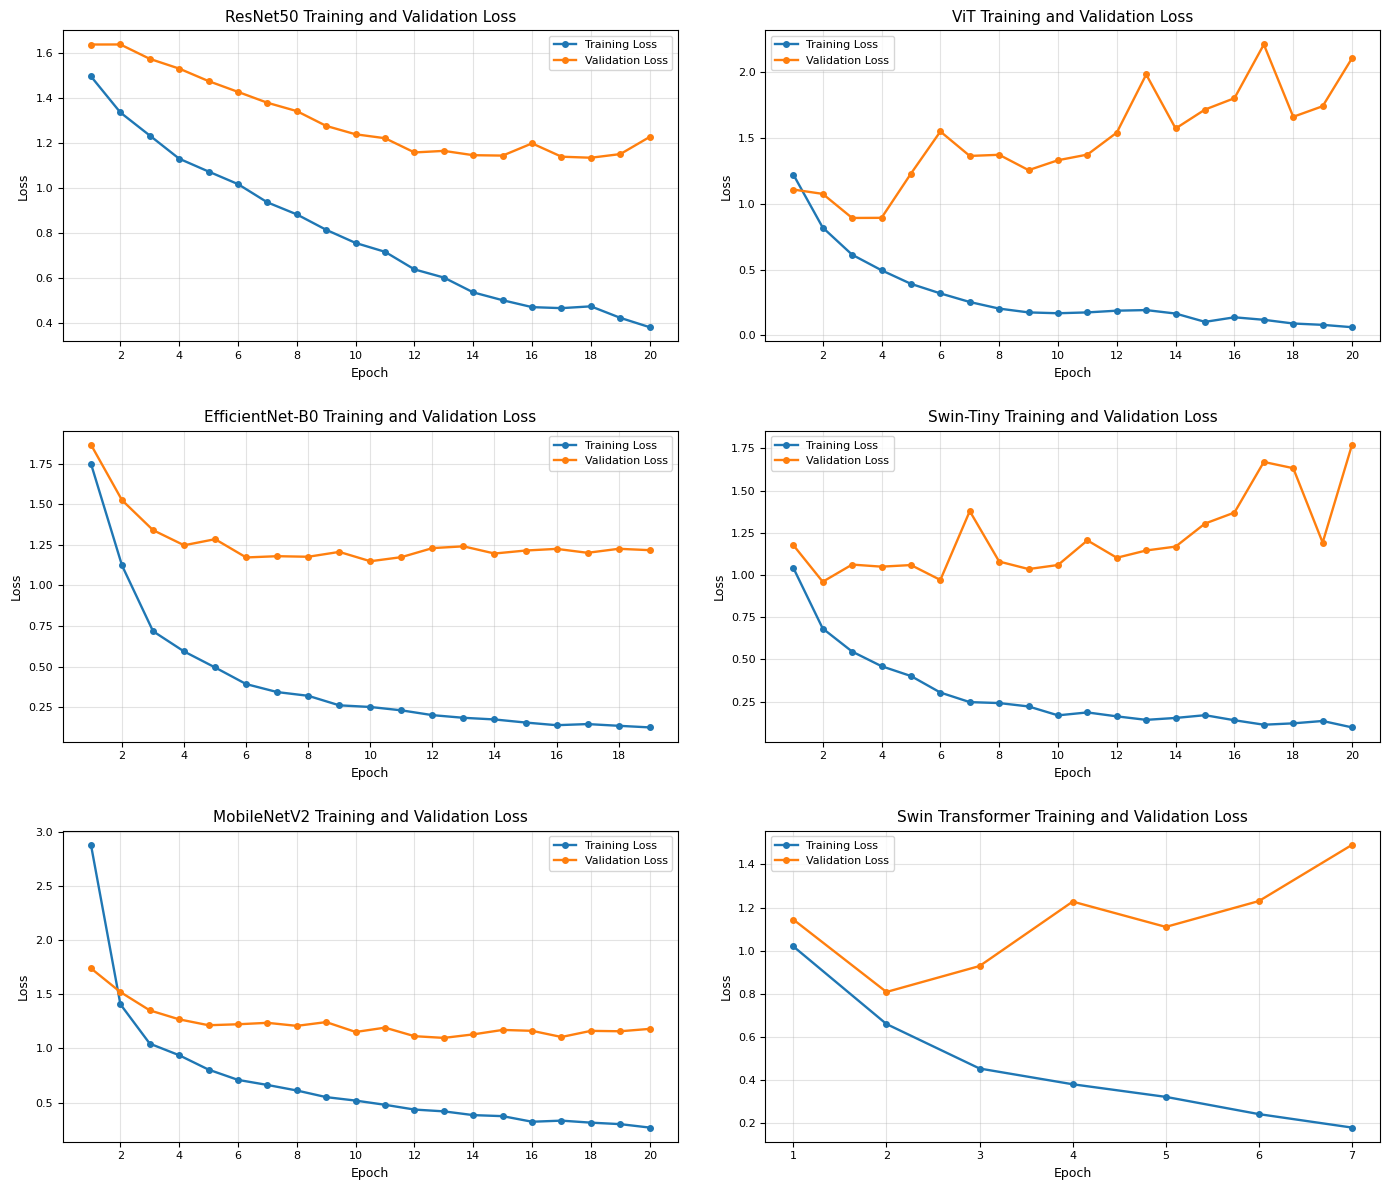

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Seed 7777 — Training and Validation Loss
# ============================================================

models = {

    "ResNet50": {
        "train": [
            1.4945, 1.3341, 1.2317, 1.1288, 1.0717,
            1.0159, 0.9348, 0.8814, 0.8129, 0.7545,
            0.7152, 0.6371, 0.6009, 0.5350, 0.5002,
            0.4695, 0.4650, 0.4730, 0.4219, 0.3803
        ],
        "val": [
            1.6360, 1.6362, 1.5723, 1.5290, 1.4734,
            1.4256, 1.3773, 1.3402, 1.2744, 1.2372,
            1.2198, 1.1566, 1.1635, 1.1444, 1.1426,
            1.1969, 1.1377, 1.1331, 1.1493, 1.2255
        ]
    },

    "ViT": {
        "train": [
            1.2225, 0.8193, 0.6128, 0.4946, 0.3913,
            0.3187, 0.2533, 0.2031, 0.1742, 0.1678,
            0.1742, 0.1873, 0.1919, 0.1655, 0.1023,
            0.1370, 0.1180, 0.0898, 0.0796, 0.0616
        ],
        "val": [
            1.1083, 1.0754, 0.8923, 0.8933, 1.2297,
            1.5498, 1.3640, 1.3726, 1.2559, 1.3313,
            1.3742, 1.5415, 1.9833, 1.5727, 1.7167,
            1.8030, 2.2115, 1.6616, 1.7421, 2.1076
        ]
    },

    "EfficientNet-B0": {
        "train": [
            1.7504, 1.1231, 0.7175, 0.5927, 0.4940,
            0.3916, 0.3423, 0.3193, 0.2606, 0.2504,
            0.2297, 0.2001, 0.1837, 0.1735, 0.1545,
            0.1381, 0.1450, 0.1344, 0.1245
        ],
        "val": [
            1.8680, 1.5257, 1.3409, 1.2476, 1.2851,
            1.1725, 1.1802, 1.1767, 1.2067, 1.1491,
            1.1743, 1.2300, 1.2411, 1.1967, 1.2151,
            1.2253, 1.2011, 1.2258, 1.2174
        ]
    },

    "Swin-Tiny": {
        "train": [
            1.0424, 0.6830, 0.5464, 0.4598, 0.4015,
            0.3037, 0.2470, 0.2414, 0.2213, 0.1686,
            0.1859, 0.1626, 0.1419, 0.1532, 0.1695,
            0.1396, 0.1131, 0.1212, 0.1352, 0.0972
        ],
        "val": [
            1.1771, 0.9601, 1.0618, 1.0495, 1.0590,
            0.9708, 1.3785, 1.0797, 1.0353, 1.0593,
            1.2051, 1.1023, 1.1454, 1.1684, 1.3049,
            1.3700, 1.6698, 1.6329, 1.1919, 1.7723
        ]
    },

    "MobileNetV2": {
        "train": [
            2.8770, 1.4070, 1.0433, 0.9364, 0.8036,
            0.7091, 0.6624, 0.6113, 0.5501, 0.5182,
            0.4794, 0.4355, 0.4188, 0.3842, 0.3747,
            0.3231, 0.3333, 0.3147, 0.3010, 0.2692
        ],
        "val": [
            1.7379, 1.5194, 1.3503, 1.2674, 1.2132,
            1.2221, 1.2354, 1.2074, 1.2421, 1.1510,
            1.1910, 1.1122, 1.0964, 1.1288, 1.1699,
            1.1616, 1.1047, 1.1613, 1.1576, 1.1796
        ]
    },

    "Swin Transformer": {
        "train": [
            1.0201, 0.6602, 0.4538, 0.3808,
            0.3223, 0.2423, 0.1799
        ],
        "val": [
            1.1446, 0.8088, 0.9291, 1.2279,
            1.1105, 1.2305, 1.4911
        ]
    }
}

# ============================================================
# Figure layout
#
# Same arrangement as your previous figure:
#
# ResNet50          ViT
# EfficientNet-B0   Swin-Tiny
# MobileNetV2       Swin Transformer
# ============================================================

layout = [
    "ResNet50",
    "ViT",
    "EfficientNet-B0",
    "Swin-Tiny",
    "MobileNetV2",
    "Swin Transformer"
]

fig, axes = plt.subplots(
    3, 2,
    figsize=(14, 12)
)

axes = axes.flatten()

for ax, model_name in zip(axes, layout):

    train_loss = models[model_name]["train"]
    val_loss = models[model_name]["val"]

    epochs = np.arange(1, len(train_loss) + 1)

    ax.plot(
        epochs,
        train_loss,
        marker="o",
        markersize=4,
        linewidth=1.7,
        label="Training Loss"
    )

    ax.plot(
        epochs,
        val_loss,
        marker="o",
        markersize=4,
        linewidth=1.7,
        label="Validation Loss"
    )

    ax.set_title(
        f"{model_name} Training and Validation Loss",
        fontsize=11
    )

    ax.set_xlabel("Epoch", fontsize=9)
    ax.set_ylabel("Loss", fontsize=9)

    ax.grid(
        True,
        alpha=0.35
    )

    ax.legend(
        fontsize=8,
        loc="best"
    )

    # Use integer epochs
    if len(epochs) <= 10:
        ax.set_xticks(epochs)
    else:
        ax.set_xticks(
            np.arange(2, len(epochs) + 1, 2)
        )

    ax.tick_params(
        axis="both",
        labelsize=8
    )

plt.tight_layout(
    h_pad=2.2,
    w_pad=2.5
)

# High-resolution manuscript figure
plt.savefig(
    "Figure_Learning_Behavior_Seed7777.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

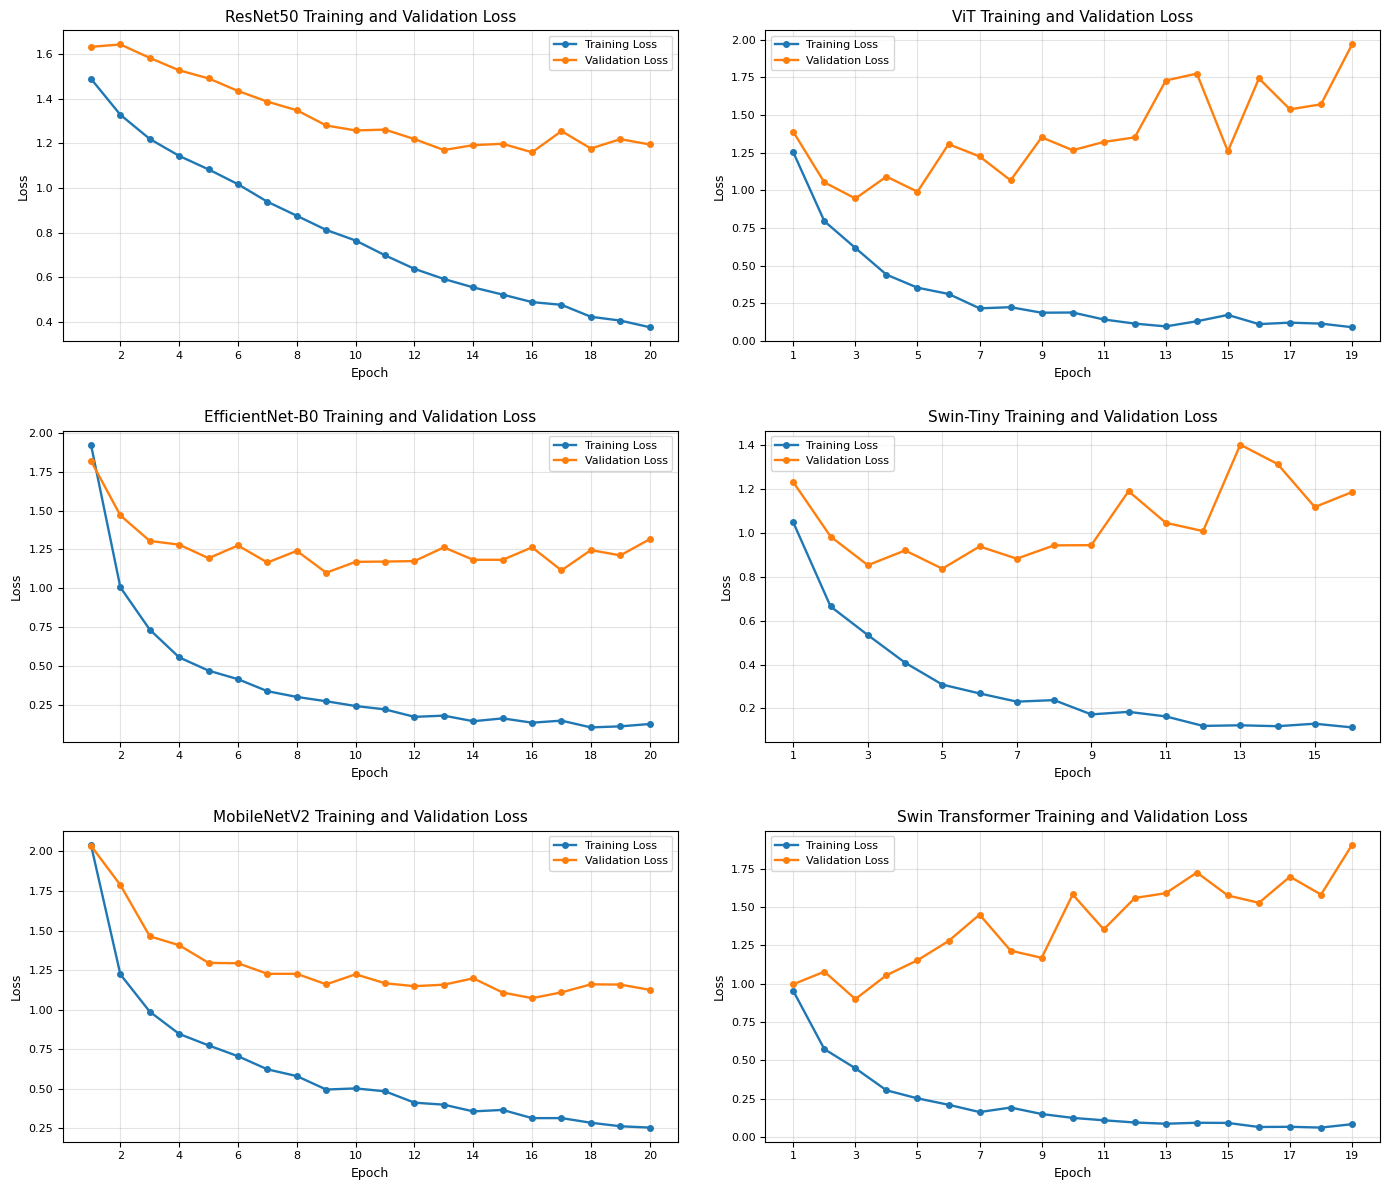

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Seed 123 — Training and Validation Loss
# ============================================================

models = {

    "ResNet50": {
        "train_loss": [
            1.4897, 1.3281, 1.2197, 1.1437, 1.0831,
            1.0167, 0.9381, 0.8753, 0.8117, 0.7642,
            0.6979, 0.6373, 0.5918, 0.5540, 0.5218,
            0.4881, 0.4759, 0.4223, 0.4053, 0.3755
        ],
        "val_loss": [
            1.6329, 1.6434, 1.5832, 1.5274, 1.4913,
            1.4348, 1.3870, 1.3484, 1.2801, 1.2579,
            1.2616, 1.2191, 1.1701, 1.1919, 1.1979,
            1.1598, 1.2550, 1.1769, 1.2187, 1.1951
        ]
    },

    "EfficientNet-B0": {
        "train_loss": [
            1.9226, 1.0069, 0.7353, 0.5573, 0.4723,
            0.4174, 0.3405, 0.3035, 0.2758, 0.2451,
            0.2236, 0.1757, 0.1835, 0.1477, 0.1659,
            0.1382, 0.1514, 0.1080, 0.1147, 0.1297
        ],
        "val_loss": [
            1.8189, 1.4685, 1.3048, 1.2809, 1.1940,
            1.2754, 1.1663, 1.2409, 1.1008, 1.1705,
            1.1723, 1.1753, 1.2634, 1.1837, 1.1836,
            1.2635, 1.1158, 1.2459, 1.2119, 1.3155
        ]
    },

    "MobileNetV2": {
        "train_loss": [
            2.0418, 1.2230, 0.9871, 0.8466, 0.7740,
            0.7058, 0.6227, 0.5801, 0.4951, 0.5022,
            0.4840, 0.4121, 0.3994, 0.3569, 0.3663,
            0.3143, 0.3146, 0.2852, 0.2630, 0.2546
        ],
        "val_loss": [
            2.0363, 1.7878, 1.4636, 1.4074, 1.2956,
            1.2935, 1.2265, 1.2266, 1.1601, 1.2235,
            1.1669, 1.1485, 1.1578, 1.1980, 1.1082,
            1.0728, 1.1092, 1.1600, 1.1586, 1.1253
        ]
    },

    "ViT": {
        "train_loss": [
            1.2522, 0.7956, 0.6179, 0.4409, 0.3543,
            0.3129, 0.2174, 0.2249, 0.1883, 0.1897,
            0.1435, 0.1161, 0.0975, 0.1316, 0.1736,
            0.1127, 0.1225, 0.1160, 0.0921
        ],
        "val_loss": [
            1.3881, 1.0531, 0.9462, 1.0915, 0.9911,
            1.3064, 1.2254, 1.0668, 1.3521, 1.2666,
            1.3213, 1.3519, 1.7290, 1.7750, 1.2593,
            1.7429, 1.5377, 1.5713, 1.9682
        ]
    },

    "Swin-Tiny": {
        "train_loss": [
            1.0477, 0.6648, 0.5343, 0.4083, 0.3084,
            0.2681, 0.2307, 0.2376, 0.1725, 0.1841,
            0.1633, 0.1200, 0.1228, 0.1187, 0.1300,
            0.1132
        ],
        "val_loss": [
            1.2316, 0.9836, 0.8530, 0.9202, 0.8369,
            0.9383, 0.8826, 0.9433, 0.9443, 1.1903,
            1.0462, 1.0085, 1.4026, 1.3144, 1.1181,
            1.1864
        ]
    },

    "Swin Transformer": {
        "train_loss": [
            0.9525, 0.5737, 0.4489, 0.3055, 0.2530,
            0.2113, 0.1636, 0.1930, 0.1510, 0.1257,
            0.1101, 0.0958, 0.0875, 0.0940, 0.0928,
            0.0663, 0.0676, 0.0625, 0.0847
        ],
        "val_loss": [
            0.9967, 1.0787, 0.9000, 1.0556, 1.1530,
            1.2783, 1.4505, 1.2157, 1.1686, 1.5817,
            1.3542, 1.5588, 1.5902, 1.7248, 1.5751,
            1.5274, 1.6978, 1.5808, 1.9052
        ]
    }
}

# Same arrangement as your previous figure
layout = [
    "ResNet50", "ViT",
    "EfficientNet-B0", "Swin-Tiny",
    "MobileNetV2", "Swin Transformer"
]

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, model in zip(axes, layout):

    train = models[model]["train_loss"]
    val = models[model]["val_loss"]

    epochs = np.arange(1, len(train) + 1)

    ax.plot(
        epochs, train,
        marker="o",
        markersize=4,
        linewidth=1.7,
        label="Training Loss"
    )

    ax.plot(
        epochs, val,
        marker="o",
        markersize=4,
        linewidth=1.7,
        label="Validation Loss"
    )

    ax.set_title(
        f"{model} Training and Validation Loss",
        fontsize=11
    )

    ax.set_xlabel("Epoch", fontsize=9)
    ax.set_ylabel("Loss", fontsize=9)

    ax.grid(True, alpha=0.35)
    ax.legend(fontsize=8, loc="best")

    if len(epochs) < 20:
        ax.set_xticks(np.arange(1, len(epochs) + 1, 2))
    else:
        ax.set_xticks(np.arange(2, 21, 2))

    ax.tick_params(axis="both", labelsize=8)

plt.tight_layout(h_pad=2.2, w_pad=2.5)

plt.savefig(
    "Figure5a_Loss_Curves_Seed123.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()